In [6]:
import numpy as np

import cellrank as cr
import scanpy as sc
import scvelo as scv
import pandas as pd

In [3]:
scv.settings.verbosity = 3
scv.settings.set_figure_params("scvelo")
sc.settings.set_figure_params(frameon=False, dpi=100)
cr.settings.verbosity = 2

In [40]:
sc.settings.figdir = "../../descriptive_results/rna_trajecotry/velocity/"
scv.settings.figdir = "../../descriptive_results/rna_trajecotry/velocity/"
cr.settings.figdir = "../../descriptive_results/rna_trajecotry/velocity/"

In [4]:
adata = sc.read("../../../2024.4_scATAC/processed_data/framework/4.29_scvi.h5ad")

In [7]:
newumap=pd.read_csv("../../../2024.4_scATAC/processed_data/embedding/RNA_scvi_umap.csv",index_col=0)
adata.obsm["X_umap"] = np.array(newumap)
drawgraph_emb = pd.read_csv("../../../2024.4_scATAC/processed_data/embedding/RNA_scvi_20neibor_drawgraph.csv",index_col=0)
adata.obsm["X_draw_graph"] = np.array(drawgraph_emb)

In [195]:
scvi = pd.read_csv("../../../2024.4_scATAC/processed_data/embedding/RNA_scvi_latent.csv",index_col=0)
adata.obsm["X_scvi"] = np.array(scvi)

In [8]:
E12_1= sc.read_loom("../../../2024.4_scATAC/data/rna/E12.5_K5mTmG_1.loom")
E12_2= sc.read_loom("../../../2024.4_scATAC/data/rna/E12.5_K5mTmG_2.loom")
E14_1= sc.read_loom("../../../2024.4_scATAC/data/rna/E14.5_K5mTmG_1.loom")
E14_2= sc.read_loom("../../../2024.4_scATAC/data/rna/E14.5_K5mTmG_2.loom")

/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [10]:
def reverse_transform(input_str):
    parts = input_str.split('_')
    sequence = parts[2].split('-')[0]
    new_string = f"{parts[0]}_K5_mTmG_{parts[1]}:{sequence}x"
    return new_string


def reverse_transform2(input_str):
    parts = input_str.split('_')
    sequence = parts[2].split('-')[0]
    new_string = f"K5mTmG_{parts[1]}:{sequence}x"
    return new_string


In [11]:
newnames = [reverse_transform(s) for s in adata.obs_names]
newnamesE14 = [reverse_transform2(s) for s in adata.obs_names]

In [13]:
E12_1.var_names_make_unique()
E12_2.var_names_make_unique()
E14_1.var_names_make_unique()
E14_2.var_names_make_unique()

In [15]:
E12_1 = E12_1[np.intersect1d(newnames,E12_1.obs_names)].copy()
E12_2 = E12_2[np.intersect1d(newnames,E12_2.obs_names)].copy()
E14_1 = E14_1[np.intersect1d(newnamesE14,E14_1.obs_names)].copy()
E14_2 = E14_2[np.intersect1d(newnamesE14,E14_2.obs_names)].copy()

In [18]:
def get_indices(lst, search_lst):
    indices = []
    for item in search_lst:
        try:
            index = lst.index(item)
            indices.append(index)
        except ValueError:
            pass
    return indices
result1 = get_indices(newnames, E12_1.obs_names)
result2 = get_indices(newnames, E12_2.obs_names)
result3 = get_indices(newnamesE14, E14_1.obs_names)
result4 = get_indices(newnamesE14, E14_2.obs_names)
E12_1.obsm["X_draw_graph"] = adata.obsm["X_draw_graph"][result1]
E12_2.obsm["X_draw_graph"] = adata.obsm["X_draw_graph"][result2]
E14_1.obsm["X_draw_graph"] = adata.obsm["X_draw_graph"][result3]
E14_2.obsm["X_draw_graph"] = adata.obsm["X_draw_graph"][result4]



E12_1.obsm["X_umap"] = adata.obsm["X_umap"][result1]
E12_2.obsm["X_umap"] = adata.obsm["X_umap"][result2]
E14_1.obsm["X_umap"] = adata.obsm["X_umap"][result3]
E14_2.obsm["X_umap"] = adata.obsm["X_umap"][result4]
annotation = pd.read_csv("../../../2024.4_scATAC/processed_data/cluster/rna_annotation_scvi_mod.csv",index_col=0)
E12_1.obs["level1_anno"] = np.array(annotation["level1_anno"][result1])
E12_2.obs["level1_anno"] = np.array(annotation["level1_anno"][result2])
E14_1.obs["level1_anno"] = np.array(annotation["level1_anno"][result3])
E14_2.obs["level1_anno"] = np.array(annotation["level1_anno"][result4])


In [196]:
E12_1.obsm["X_scvi"] = adata.obsm["X_scvi"][result1]
E12_2.obsm["X_scvi"] = adata.obsm["X_scvi"][result2]
E14_1.obsm["X_scvi"] = adata.obsm["X_scvi"][result3]
E14_2.obsm["X_scvi"] = adata.obsm["X_scvi"][result4]

In [190]:
pseudotime = pd.read_csv("../../../2024.4_scATAC/processed_data/trajectory/5.1_rna_celloracle.pseudotime_run2.csv",index_col=0)

In [191]:
E12_1.obs["Pseudotime"] = np.array(pseudotime["Pseudotime"][result1])
E12_2.obs["Pseudotime"] = np.array(pseudotime["Pseudotime"][result2])
E14_1.obs["Pseudotime"] = np.array(pseudotime["Pseudotime"][result3])
E14_2.obs["Pseudotime"] = np.array(pseudotime["Pseudotime"][result4])

In [197]:
adata_velo = sc.concat([E12_1,E12_2,E14_1,E14_2])

In [23]:
adata_velo

AnnData object with n_obs × n_vars = 19422 × 25954
    obs: 'level1_anno', 'Pseudotime'
    obsm: 'X_draw_graph', 'X_umap'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [24]:
def velo(run_adata):
    scv.pp.filter_and_normalize(
        run_adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=False
    )
    
    sc.tl.pca(run_adata)
    sc.pp.neighbors(run_adata, n_pcs=30, n_neighbors=30, random_state=0)
    scv.pp.moments(run_adata, n_pcs=None, n_neighbors=None)
    scv.tl.recover_dynamics(run_adata, n_jobs=18)
    scv.tl.velocity(run_adata, mode="dynamical")


In [25]:
velo(adata_velo)

Filtered out 14539 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.
computing moments based on connectivities
    finished (0:00:28) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 18/48 cores)


  0%|          | 0/1335 [00:00<?, ?gene/s]

    finished (0:08:07) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:56) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [26]:
def run_plot(adata_run):
    vk_run = cr.kernels.VelocityKernel(adata_run)
    vk_run.compute_transition_matrix()
    return(vk_run)

In [27]:
vk = run_plot(adata_velo)

Computing transition matrix using `'deterministic'` model


  0%|          | 0/19422 [00:00<?, ?cell/s]

Using `softmax_scale=4.8906`


  0%|          | 0/19422 [00:00<?, ?cell/s]

    Finish (0:01:43)


Using precomputed projection `adata.obsm['T_fwd_umap']`


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


saving figure to file ../../descriptive_results/rna_trajecotry/velocity/scvelo__velo_umap.pdf


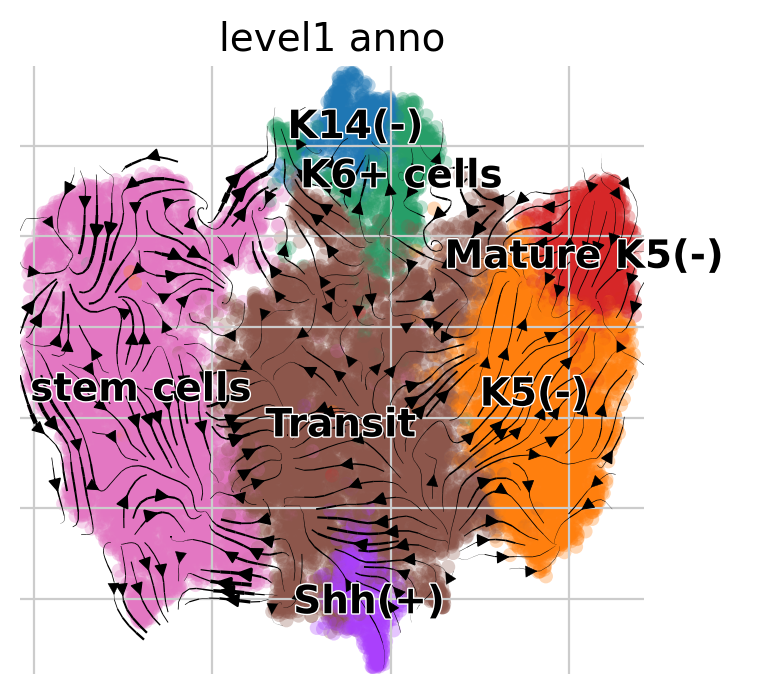

In [43]:
vk.plot_projection(color = "level1_anno",save="_velo_umap.pdf")

Using precomputed projection `adata.obsm['T_fwd_draw_graph']`


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


figure cannot be saved as pdf, using png instead (can only output finite numbers in pdf).
saving figure to file ../../descriptive_results/rna_trajecotry/velocity/scvelo__velo_drawgraph.png


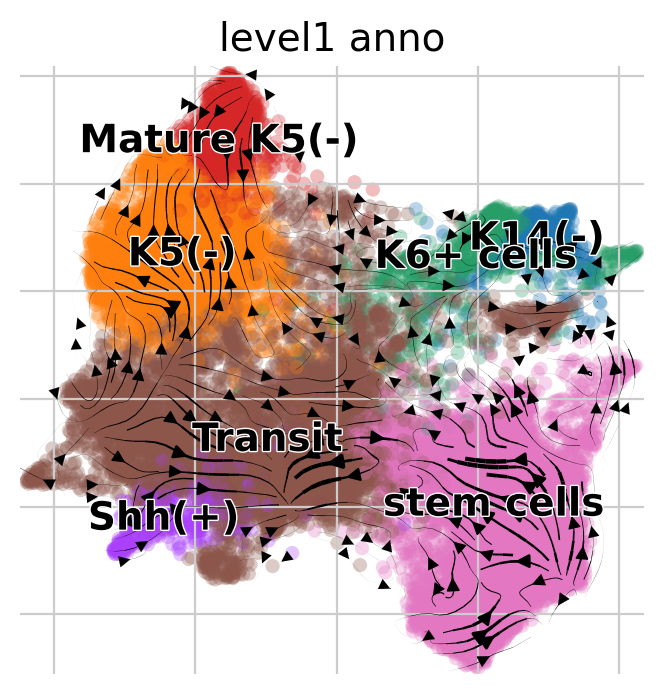

In [42]:
vk.plot_projection(basis="X_draw_graph",color = "level1_anno",save="_velo_drawgraph.pdf")

In [32]:
vk.write_to_adata()

In [34]:
scv.tl.velocity_graph(adata_velo)

computing velocity graph (using 1/48 cores)


  0%|          | 0/19422 [00:00<?, ?cells/s]

    finished (0:05:27) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [35]:
def runVeloPaga(adata_run):
    scv.tl.velocity_graph(adata_run,n_jobs=20)
    adata_run.uns['neighbors']['distances'] = adata_run.obsp['distances']
    adata_run.uns['neighbors']['connectivities'] = adata_run.obsp['connectivities']
    
    scv.tl.paga(adata_run, groups='level1_anno')
    df = scv.get_df(adata_run, 'paga/transitions_confidence', precision=2).T
    return df
    #df.style.background_gradient(cmap='Blues').format('{:.2g}')

In [36]:
df = runVeloPaga(adata_velo)

computing velocity graph (using 20/48 cores)


  0%|          | 0/19422 [00:00<?, ?cells/s]

    finished (0:01:13) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 2 regions of end points .
    finished (0:00:05) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']


ModuleNotFoundError: No module named 'igraph'

In [188]:
adata_velo_bk.obs["velocity_pseudotime"] = adata_velo_bk.obs["Pseudotime"]

In [200]:
adata_velo

AnnData object with n_obs × n_vars = 19422 × 25954
    obs: 'level1_anno', 'Pseudotime'
    obsm: 'X_draw_graph', 'X_umap', 'X_scvi'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [201]:
adata_velo_bk.obsm["X_scvi"] = adata_velo.obsm["X_scvi"]

In [ ]:
adata_velo_bk.obsm["X_scvi"] = adata_velo.obsm["X_scvi"]

In [203]:
adata_velo.obsm["X_scvi"].shape

(19422, 30)

In [204]:
sc.pp.neighbors(adata_velo_bk, n_neighbors=4, n_pcs=30,use_rep="X_scvi")

running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:10) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


saving figure to file ../../descriptive_results/rna_trajecotry/velocity/scvelo__velo_paga.pdf


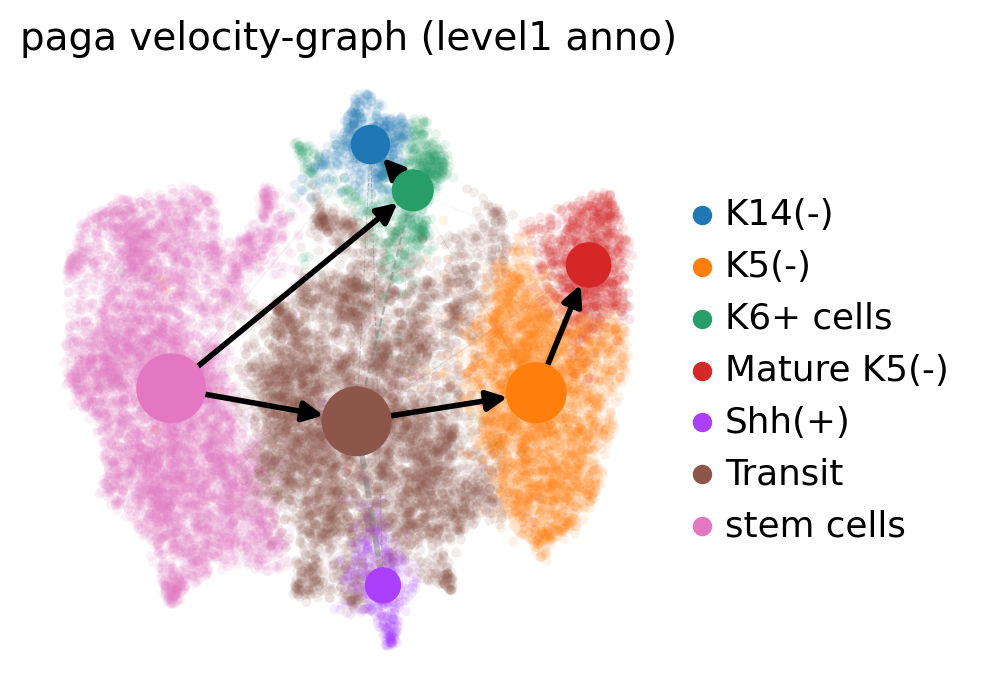

In [189]:
scv.tl.paga(adata_velo_bk, groups='level1_anno')
scv.pl.paga(adata_velo_bk, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5,save="_velo_paga.pdf")

running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:10) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


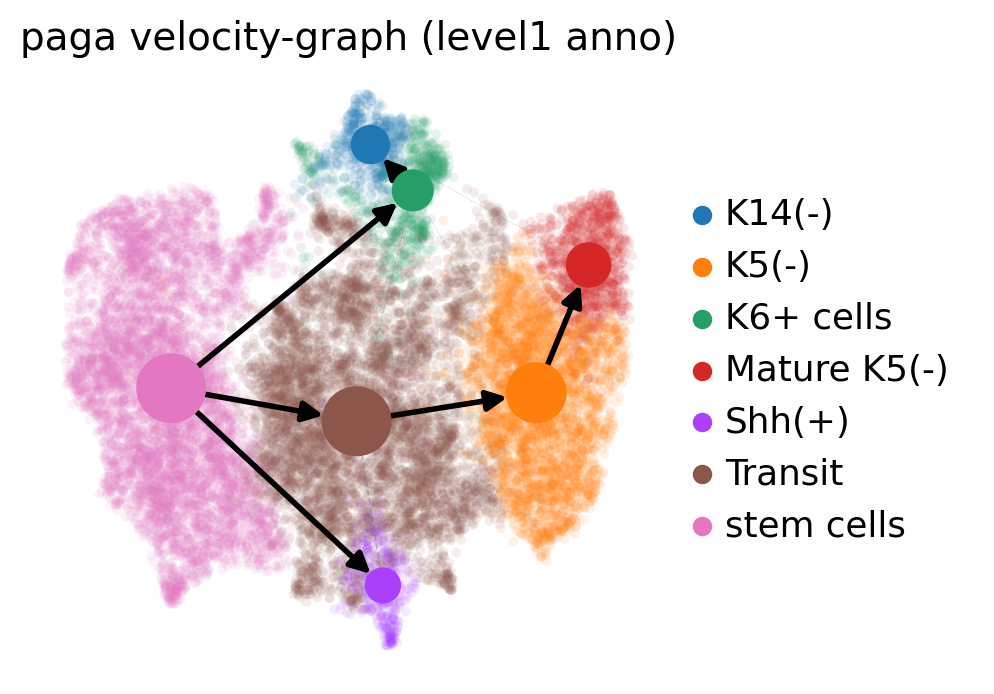

In [205]:
scv.tl.paga(adata_velo_bk, groups='level1_anno')
scv.pl.paga(adata_velo_bk, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5)

running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:10) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


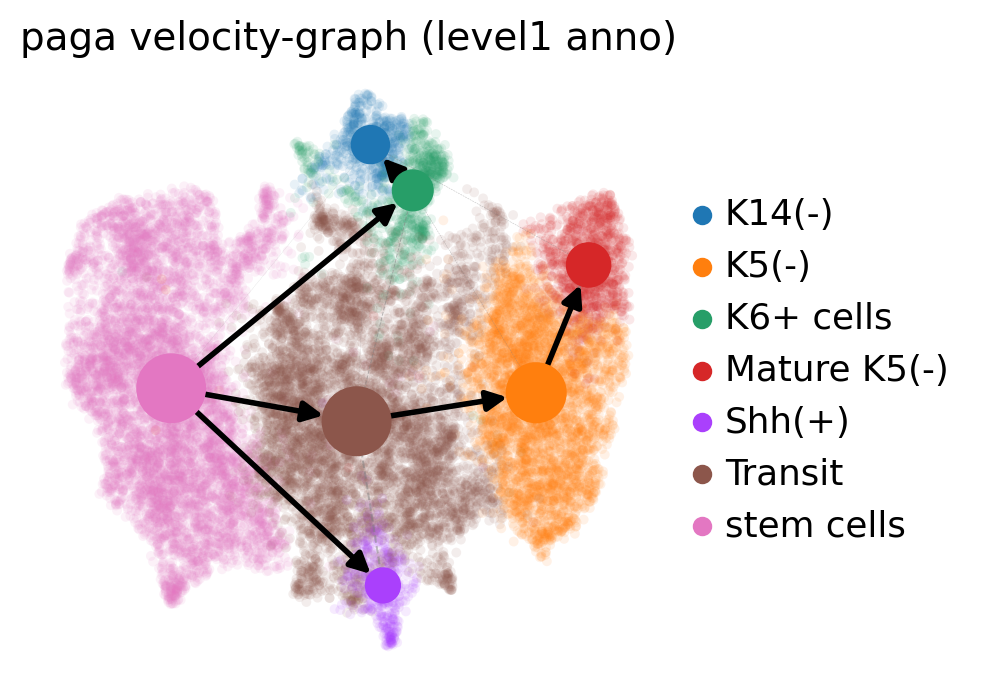

In [209]:
sc.pp.neighbors(adata_velo_bk, n_neighbors=6, n_pcs=30,use_rep="X_scvi")
scv.tl.paga(adata_velo_bk, groups='level1_anno')
scv.pl.paga(adata_velo_bk, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5)

In [210]:
adata_velo_bk.obs["velocity_pseudotime"] = adata_velo.obs["Pseudotime"] 

running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:10) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


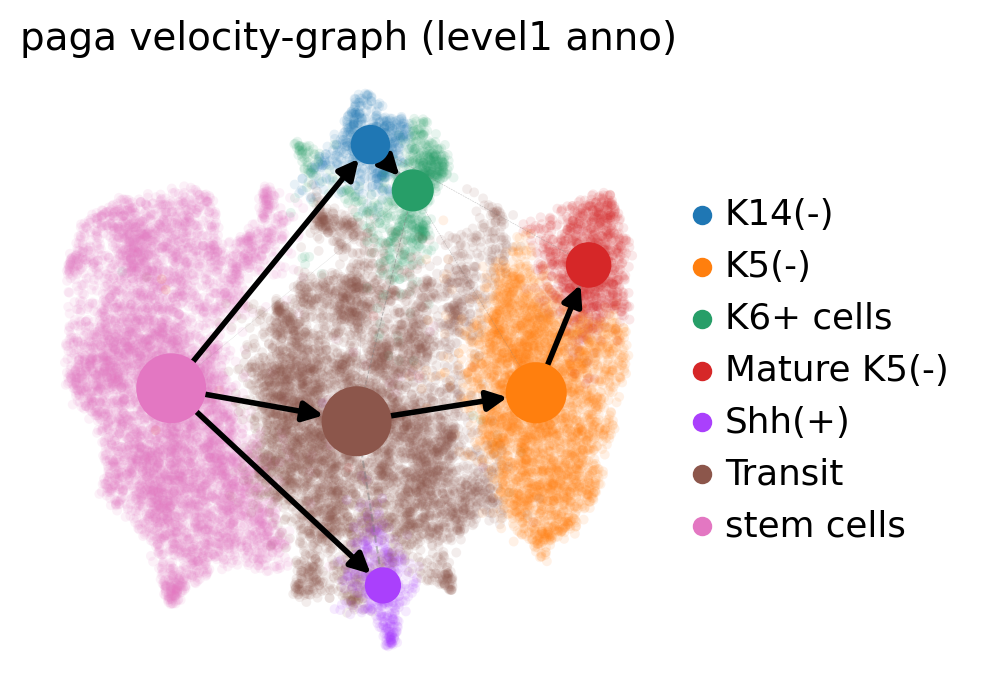

In [211]:
scv.tl.paga(adata_velo_bk, groups='level1_anno')
scv.pl.paga(adata_velo_bk, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5,save="_paga_directed.pdf")

/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


saving figure to file ../../descriptive_results/rna_trajecotry/velocity/scvelo__paga_directed.pdf


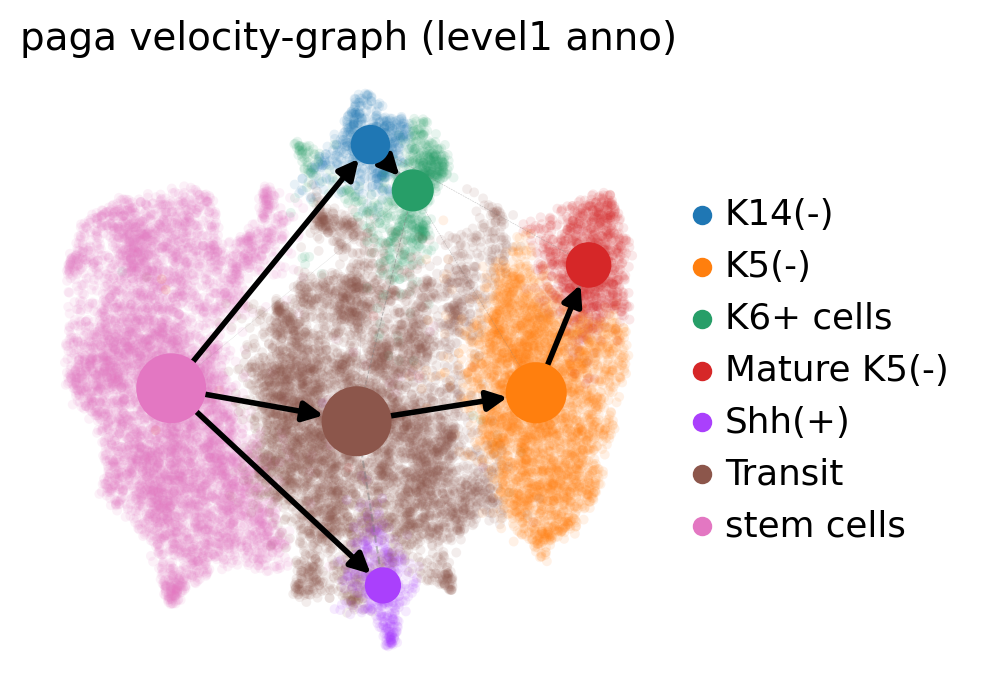

In [212]:
scv.pl.paga(adata_velo_bk, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5,save="_paga_directed.pdf")

/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


saving figure to file ../../descriptive_results/rna_trajecotry/velocity/scvelo__paga_directed_drawgraph.pdf


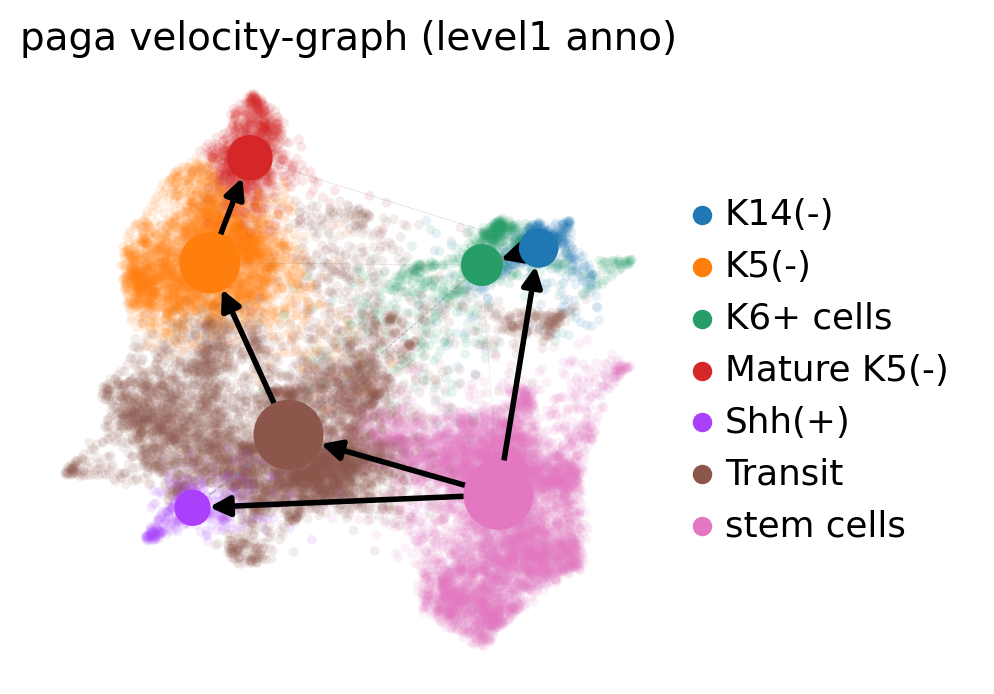

In [221]:
scv.pl.paga(adata_velo_bk, basis='draw_graph', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5,save="_paga_directed_drawgraph.pdf")

In [223]:
del adata_velo_bk.layers

In [226]:
del adata_velo_bk.X

In [228]:
adata_velo_bk.write_h5ad("../../../2024.4_scATAC/processed_data/framework/velocity/20241005_merge_paga.h5ad")

In [220]:
adata_velo_bk.uns["paga"]["connectivities_tree"].toarray()

array([[0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.36045974, 0.        ,
        0.08784907, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.12322786, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.24443228, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.06340814],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ]])

In [37]:
scv.tl.paga(adata_velo, groups='level1_anno')

running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:11) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


saving figure to file ../../descriptive_results/rna_trajecotry/velocity/scvelo__velo_paga.pdf


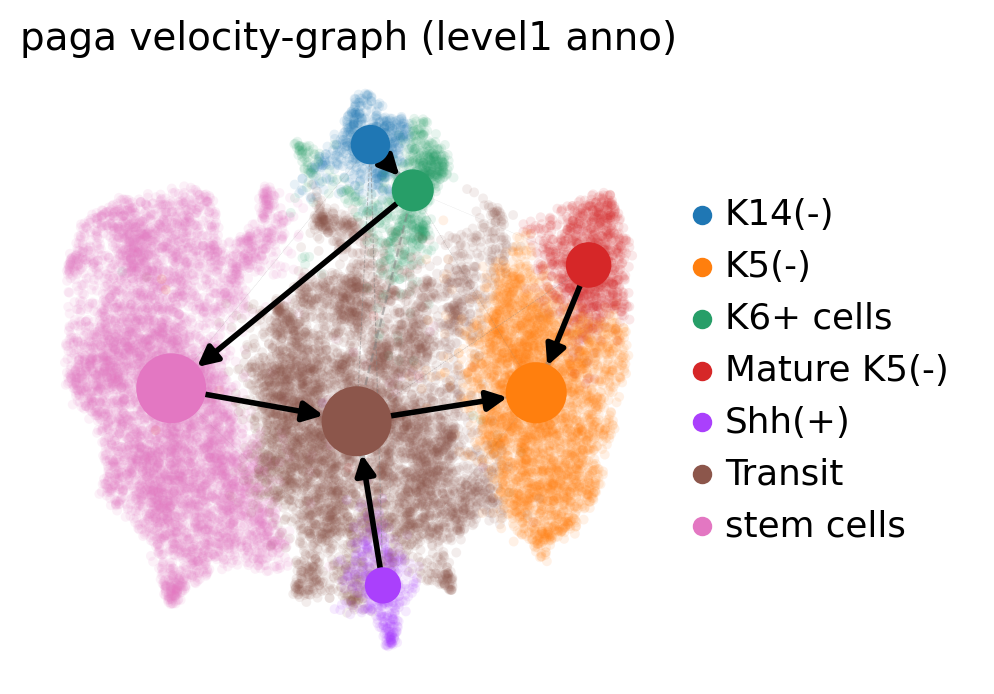

In [41]:
scv.pl.paga(adata_velo, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5,save="_velo_paga.pdf")

In [66]:
adata_velo.obsp["T_fwd"]

<19422x19422 sparse matrix of type '<class 'numpy.float64'>'
	with 784130 stored elements in Compressed Sparse Row format>

In [68]:
adata_combine.obsp["T_fwd"]

<19404x19404 sparse matrix of type '<class 'numpy.float64'>'
	with 391890 stored elements in Compressed Sparse Row format>

In [70]:
adata_velo.obsp["T_fwd_bk"] = adata_velo.obsp["T_fwd"].copy()

In [71]:
adata_velo.obsp["T_fwd"] = adata_combine.obsp["T_fwd"]

ValueError: Value passed for key 'T_fwd' is of incorrect shape. Values of obsp must match dimensions ('obs', 'obs') of parent. Value had shape (19404, 19404) while it should have had (19422, 19422).

In [115]:
name1 = [reverse_transform(s) for s in adata_combine.obs_names[adata_combine.obs["time"] == 12.5]]
name2 = [reverse_transform2(s) for s in adata_combine.obs_names[adata_combine.obs["time"] == 14.5]]

In [116]:
list1 = name1 + name2

In [86]:
obsName = np.array(adata_velo.obs_names)

In [118]:
len(np.intersect1d(list1,adata_velo.obs_names))

19404

In [140]:
adata_velo

AnnData object with n_obs × n_vars = 19422 × 11415
    obs: 'level1_anno', 'Pseudotime', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime'
    var: 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'recover_dynamics', 'velocity_params', 'T_fwd_params', 'level1_anno_colors', 'velocity_graph', 'velocity_graph_neg', 'paga', 'level1_anno_sizes'
    obsm: 'X_draw_graph', 'X_umap', 'X_pca', 'T_fwd_umap', 'T_fwd_draw_graph'
    varm: 'PCs', 'loss'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced', 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'velocity', 'velocity_u'
    o

In [172]:
adata_velo_bk = adata_velo.copy()

In [173]:
del adata_velo.obsp

In [186]:
adata_velo

AnnData object with n_obs × n_vars = 19422 × 11415
    obs: 'level1_anno', 'Pseudotime', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime'
    var: 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'recover_dynamics', 'velocity_params', 'T_fwd_params', 'level1_anno_colors', 'velocity_graph', 'velocity_graph_neg', 'paga', 'level1_anno_sizes'
    obsm: 'X_draw_graph', 'X_umap', 'X_pca', 'T_fwd_umap', 'T_fwd_draw_graph'
    varm: 'PCs', 'loss'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced', 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'velocity', 'velocity_u'

In [175]:
adata_velo_sub = adata_velo[np.intersect1d(list1,adata_velo.obs_names)].copy()

In [184]:
del adata_velo_sub.uns

In [153]:
bool1 = np.isin(adata_velo.obs_names,list1)

In [155]:
len(bool1)

19422

In [133]:
arr = np.array(adata_velo_sub.obs["Pseudotime"]).copy()

In [165]:
dist= adata_velo.obsp["distances"].toarray()[bool1][:, bool1]

In [166]:
from scipy.sparse import csr_matrix

dist = csr_matrix(dist)

In [168]:
dist.shape

(19404, 19404)

In [44]:
adata_velo.write_h5ad("../../../2024.4_scATAC//processed_data/framework/velocity/merge_velo.h5ad")

In [45]:
adata_combine = sc.read("../../../2024.4_scATAC/processed_data/framework/5.26_cellrank_ck.h5ad")